In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [2]:
df = sns.load_dataset('dowjones')

# Zapoznanie ze zbiorem danych

In [3]:
df.head(10)

,Date,Price
0,1914-12-01,55.00
1,1915-01-01,56.55
2,1915-02-01,56.00
3,1915-03-01,58.30
4,1915-04-01,66.45
5,1915-05-01,65.95
6,1915-06-01,68.40
7,1915-07-01,71.85
8,1915-08-01,79.25
9,1915-09-01,85.50


In [4]:
df.describe()

,Date,Price
count,649,649.000000
mean,1941-11-30 17:42:48.258859776,290.807319
min,1914-12-01 00:00:00,46.850000
25%,1928-06-01 00:00:00,106.900000
50%,1941-12-01 00:00:00,172.270000
75%,1955-06-01 00:00:00,436.730000
max,1968-12-01 00:00:00,985.930000
std,NaN,256.062906


In [5]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,649,1941-11-30 17:42:48.258859776,1914-12-01 00:00:00,1928-06-01 00:00:00,1941-12-01 00:00:00,1955-06-01 00:00:00,1968-12-01 00:00:00,NaN
Price,649.0,290.807319,46.85,106.9,172.27,436.73,985.93,256.062906


In [6]:
df.describe(include='all')

,Date,Price
count,649,649.000000
mean,1941-11-30 17:42:48.258859776,290.807319
min,1914-12-01 00:00:00,46.850000
25%,1928-06-01 00:00:00,106.900000
50%,1941-12-01 00:00:00,172.270000
75%,1955-06-01 00:00:00,436.730000
max,1968-12-01 00:00:00,985.930000
std,NaN,256.062906


In [7]:
df.isnull().sum()

Date     0
Price    0
dtype: int64

In [8]:
df.shape

(649, 2)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    649 non-null    datetime64[ns]
 1   Price   649 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 10.3 KB


In [10]:
df.dtypes

Date     datetime64[ns]
Price           float64
dtype: object

In [11]:
df.columns.tolist()

['Date', 'Price']

# Wykres przedstawia jak zmieniał się rynek na przestrzeni lat 1914-1968

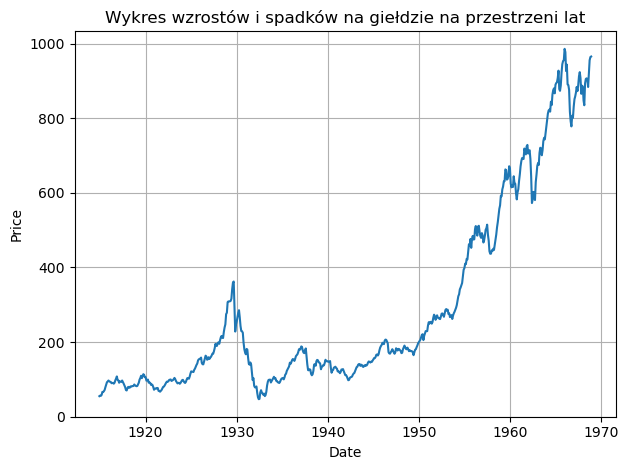

In [12]:
sns.lineplot(x='Date', y='Price', data=df)
plt.title('Wykres wzrostów i spadków na giełdzie na przestrzeni lat')
plt.tight_layout()
plt.grid()
plt.show()

In [13]:
print(f'Początek notowań na giełdzie: {df['Date'].min().date()}, ostatnie notowanie na giełdzie: {df['Date'].max().date()}')

Początek notowań na giełdzie: 1914-12-01, ostatnie notowanie na giełdzie: 1968-12-01


In [14]:
df['days'] = (df['Date'] - df['Date'].min()).dt.days

In [15]:
df

,Date,Price,days
0,1914-12-01,55.00,0
1,1915-01-01,56.55,31
2,1915-02-01,56.00,62
3,1915-03-01,58.30,90
4,1915-04-01,66.45,121
...,...,...,...
644,1968-08-01,883.72,19602
645,1968-09-01,922.80,19633
646,1968-10-01,955.47,19663
647,1968-11-01,964.12,19694


# Trenowanie modelu regresji liniowej na wszystkich danych w celu obliczenia parametrów funkcji liniowej: współczynnik nachylenia (a), wyraz wolny (b) -> y = ax + b

In [16]:
X = df[['days']]
y = df['Price']

In [17]:
model_lin_reg = LinearRegression()
model_lin_reg.fit(X, y)

LinearRegression()

# Współczynnik nachylenia jest dodatni, zatem wykres będzie rosnący

In [18]:
print(f'Wzór funkcji liniowej dla datasetu dowjones: y = {model_lin_reg.coef_[0]:.3f}*x + {model_lin_reg.intercept_:.3f}')

Wzór funkcji liniowej dla datasetu dowjones: y = 0.037*x + -74.845


# Na obu wykresach widać, że trend na giełdzie jest wzrostowy dla cen

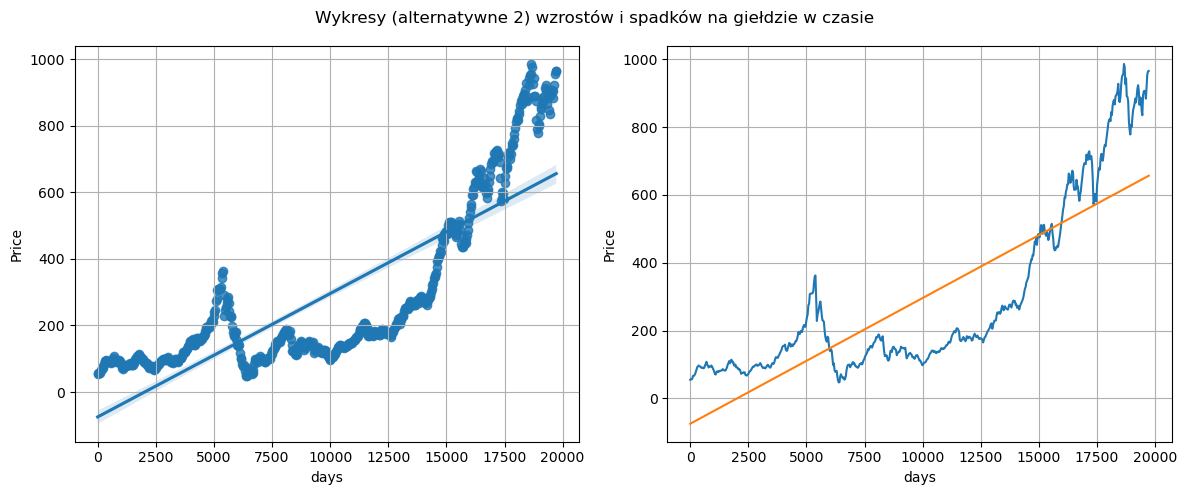

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

fig.suptitle('Wykresy (alternatywne 2) wzrostów i spadków na giełdzie w czasie')

sns.regplot(data=df, x='days', y='Price', ax=ax[0])
ax[0].grid()

sns.lineplot(data=df, x='days', y='Price', ax=ax[1])
ax[1].plot([df['days'].min(), df['days'].max()], [model_lin_reg.coef_[0] * x + model_lin_reg.intercept_ for x in [df['days'].min(), df['days'].max()]])
ax[1].grid()

plt.tight_layout()
plt.show()